In [1]:
import pandas as pd
import ast

In [2]:
needed_columns = ['movie_name', 'genres', 'emotion']

df = pd.read_csv(r'../data/movies.csv', usecols=needed_columns)
 
df.head()

,movie_name,genres,emotion
0,Waiting to Exhale,"['Comedy', 'Drama', 'Romance']",anticipation
1,Waiting to Exhale,"['Comedy', 'Drama', 'Romance']",anticipation
2,Waiting to Exhale,"['Comedy', 'Drama', 'Romance']",anticipation
3,Waiting to Exhale,"['Comedy', 'Drama', 'Romance']",anticipation
4,Waiting to Exhale,"['Comedy', 'Drama', 'Romance']",anticipation


In [3]:
df.drop_duplicates(inplace=True)
df.shape[0]

3067

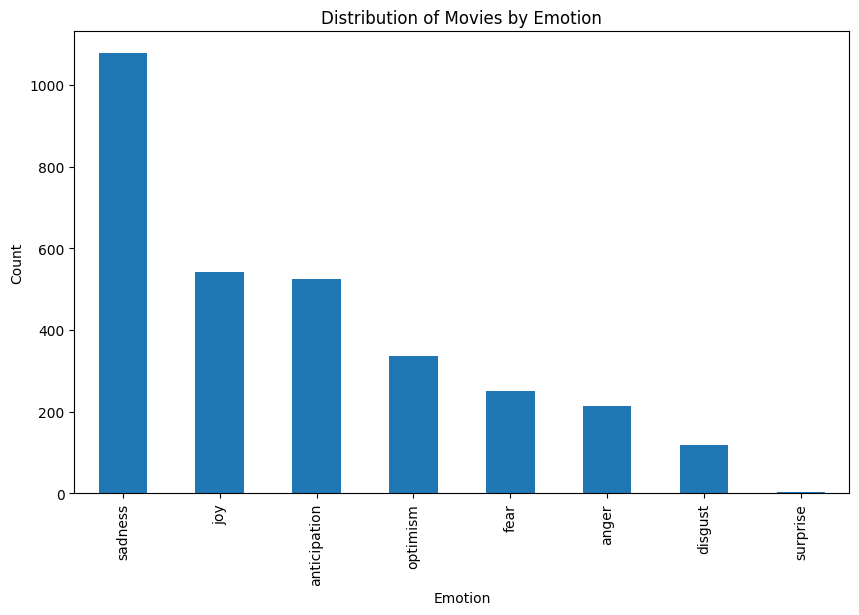

In [4]:
import matplotlib.pyplot as plt

emotion_counts = df['emotion'].value_counts()

plt.figure(figsize=(10, 6))
emotion_counts.plot(kind='bar')
plt.title('Distribution of Movies by Emotion')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.show()

In [5]:
df['genres'] = df['genres'].apply(ast.literal_eval)     

"""This is a common "gotcha" in Data Science! When you save a list (like ['Comedy', 'Drama']) into a CSV file, 
Pandas saves it as a String (text), not a real Python List.

The code df['genres'].apply(ast.literal_eval) is the "magic wand" that turns that text back into a usable Python list."""

'This is a common "gotcha" in Data Science! When you save a list (like [\'Comedy\', \'Drama\']) into a CSV file, \nPandas saves it as a String (text), not a real Python List.\n\nThe code df[\'genres\'].apply(ast.literal_eval) is the "magic wand" that turns that text back into a usable Python list.'

In [6]:
df_exploded = df.explode('genres')

In [7]:
df_exploded.head()

,movie_name,genres,emotion
0,Waiting to Exhale,Comedy,anticipation
0,Waiting to Exhale,Drama,anticipation
0,Waiting to Exhale,Romance,anticipation
8,Father of the Bride Part II,Comedy,sadness
26,Heat,Action,disgust


In [8]:
genre_counts = df_exploded.groupby(['emotion', 'genres']).size().unstack(fill_value=0)

In [9]:
def get_top_genres(df_matrix, top_n=5):
    mood_map = {}
    for emotion in df_matrix.index:
        # For each emotion (row), sort the counts and pick the top N genre names (columns)
        top_list = df_matrix.loc[emotion].sort_values(ascending=False).head(top_n).index.tolist()
        mood_map[emotion] = top_list
    return mood_map

In [10]:
FINAL_MOOD_MAP = get_top_genres(genre_counts)

print("Mapping dictionary: \n")
for mood, genres in FINAL_MOOD_MAP.items():
    print(f"{mood}: {genres}")

Mapping dictionary: 

anger: ['Drama', 'Romance', 'Comedy', 'Action', 'Thriller']
anticipation: ['Drama', 'Romance', 'Comedy', 'Thriller', 'Action']
disgust: ['Comedy', 'Drama', 'Romance', 'Thriller', 'Action']
fear: ['Drama', 'Romance', 'Thriller', 'Comedy', 'Action']
joy: ['Drama', 'Romance', 'Comedy', 'Thriller', 'Family']
optimism: ['Drama', 'Comedy', 'Romance', 'Thriller', 'Action']
sadness: ['Drama', 'Romance', 'Comedy', 'Thriller', 'Action']
surprise: ['Romance', 'Drama', 'Crime', 'Thriller', 'Mystery']


In [11]:
req_col = ['genres', 'original_title', 'original_language', 'release_date', 'popularity']
df = pd.read_csv(r'../data/movies_dataset.csv', usecols=req_col)
df.head()

,genres,original_language,original_title,popularity,release_date
0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,Avatar,150.437577,2009-12-10
1,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",en,Pirates of the Caribbean: At World's End,139.082615,2007-05-19
2,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,Spectre,107.376788,2015-10-26
3,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",en,The Dark Knight Rises,112.312950,2012-07-16
4,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,John Carter,43.926995,2012-03-07


In [12]:
df['genres'].head()

0    [{"id": 28, "name": "Action"}, {"id": 12, "nam...
1    [{"id": 12, "name": "Adventure"}, {"id": 14, "...
2    [{"id": 28, "name": "Action"}, {"id": 12, "nam...
3    [{"id": 28, "name": "Action"}, {"id": 80, "nam...
4    [{"id": 28, "name": "Action"}, {"id": 12, "nam...
Name: genres, dtype: str

In [13]:
def extract_genres(text):
    try:
        genres = ast.literal_eval(text)
        return [g['name'] for g in genres]
    except:
        return []

df['genres'] = df['genres'].apply(extract_genres)

In [14]:
df['genres'].head()

0    [Action, Adventure, Fantasy, Science Fiction]
1                     [Adventure, Fantasy, Action]
2                       [Action, Adventure, Crime]
3                 [Action, Crime, Drama, Thriller]
4             [Action, Adventure, Science Fiction]
Name: genres, dtype: object